In [28]:
# ============================================================
# 03_modeling.ipynb — Modélisation complète (v2 — corrigée)
# Fixes : last24h intégrées, NaN-natif XGB/LGB,
#         early stopping interne, winso sur valeurs brutes
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    brier_score_loss, roc_curve, precision_recall_curve,
    confusion_matrix
)
from sklearn.calibration import calibration_curve

import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import os
os.makedirs('../figures', exist_ok=True)

# ── Palette cohérente avec les autres notebooks ────────────
NAVY  = '#1B2A4A'
BLUE  = '#2563EB'
TEAL  = '#0D9488'
RED   = '#DC2626'
GRAY  = '#6B7280'
LGRAY = '#F3F4F6'

RANDOM_STATE = 42
N_FOLDS      = 5

print("✓ Imports OK")
print(f"  XGBoost  : {xgb.__version__}")
print(f"  LightGBM : {lgb.__version__}")

✓ Imports OK
  XGBoost  : 3.2.0
  LightGBM : 4.6.0


In [29]:
# ============================================================
# CHARGEMENT — Tous les blocs du 02_features
# Inclut les features last-24h manquantes dans features_all
# ============================================================

print("Chargement des parquets...")

df_base    = pd.read_parquet('../data/features_all.parquet')
df_last24h = pd.read_parquet('../data/features_last24h.parquet')
df_gcs     = pd.read_parquet('../data/features_gcs_total.parquet')

print(f"  features_all   : {df_base.shape}")
print(f"  features_last24h: {df_last24h.shape}")
print(f"  features_gcs   : {df_gcs.shape}")

# ── Fusion ────────────────────────────────────────────────
df = df_base.merge(df_last24h, on='stay_id', how='left')
df = df.merge(df_gcs,     on='stay_id', how='left')

print(f"\n✓ Dataset fusionné : {df.shape[0]:,} séjours × {df.shape[1]} colonnes")

# ── Vérification targets ──────────────────────────────────
print("\nTargets :")
for t in ['readmit_7d', 'readmit_14d', 'readmit_30d']:
    n = df[t].sum()
    print(f"  {t} : {n:,} positifs ({n/len(df)*100:.1f}%)")

Chargement des parquets...
  features_all   : (59260, 102)
  features_last24h: (59260, 11)
  features_gcs   : (59260, 2)

✓ Dataset fusionné : 59,260 séjours × 113 colonnes

Targets :
  readmit_7d : 3,144 positifs (5.3%)
  readmit_14d : 3,709 positifs (6.3%)
  readmit_30d : 3,922 positifs (6.6%)


In [35]:
# ============================================================
# PRÉPARATION — Features finales, cibles, groupes
# ============================================================

EXCLUDE = [
    'stay_id', 'subject_id', 'hadm_id',
    'readmit_7d', 'readmit_14d', 'readmit_30d',
    'first_careunit', 'anchor_year_group',
    'los_hours',
    'gcs_last', 'gcs_min',
]

# Features composites post-merge
df['bun_creatinine_ratio'] = (
    df['bun_last'] / df['creatinine_last'].replace(0, np.nan)
)

df['hr_last24h_std'] = df['hr_last24h_std'].where(
    df['hr_last24h_count'] >= 2, other=np.nan
)

feature_cols = [c for c in df.columns if c not in EXCLUDE]

# ── FIX : conversion explicite en float64 numpy-compatible ──
# pd.NA (nullable integer) != np.nan → astype(float) plante
# .astype(object) puis convert_dtypes règle le problème proprement
X = df[feature_cols].copy()
X = X.apply(lambda col: pd.to_numeric(col, errors='coerce'))  # pd.NA → np.nan
X = X.astype(np.float64)                                       # tout en float64

y      = df['readmit_7d'].copy().astype(int)
groups = df['subject_id'].values

ratio = (y == 0).sum() / (y == 1).sum()

print(f"✓ X      : {X.shape[0]:,} × {X.shape[1]} features")
print(f"✓ y      : {y.sum():,} positifs ({y.mean()*100:.1f}%)")
print(f"✓ groups : {len(np.unique(groups)):,} patients uniques")
print(f"✓ ratio  : {ratio:.1f}")

# Vérification : aucun pd.NA résidue

✓ X      : 59,260 × 104 features
✓ y      : 3,144 positifs (5.3%)
✓ groups : 47,467 patients uniques
✓ ratio  : 17.8


In [36]:
# ============================================================
# BASELINE — SWIFT Score
# (GCS total déjà calculé dans gcs_total_last)
# ============================================================

def compute_swift(row):
    score = 0
    # 1. Source admission
    score += 0 if row['from_ed'] == 1 else 8
    # 2. LOS ICU
    los = row['los_days']
    score += 14 if los > 10 else 1 if los >= 2 else 0
    # 3. PaO2/FiO2 (manquant → valeur normale)
    pf = row['pf_ratio_last'] if pd.notna(row['pf_ratio_last']) else 400
    score += 13 if pf < 100 else 10 if pf < 150 else 5 if pf < 400 else 0
    # 4. GCS total (manquant → 15)
    gcs = row['gcs_total_last'] if pd.notna(row['gcs_total_last']) else 15
    score += 24 if gcs < 8 else 14 if gcs < 11 else 6 if gcs < 14 else 0
    # 5. PaCO2 (manquant → normal)
    paco2 = row['paco2_last'] if pd.notna(row['paco2_last']) else 40
    score += 5 if paco2 > 45 else 0
    return score

print("Calcul SWIFT score...")
df['swift_score'] = df.apply(compute_swift, axis=1)

swift_norm = df['swift_score'] / 64   # normalisation 0-1 pour Brier

SWIFT_AUROC = roc_auc_score(y, df['swift_score'])
SWIFT_PRAUC = average_precision_score(y, df['swift_score'])
SWIFT_BRIER = brier_score_loss(y, swift_norm)

print(f"\n=== BASELINE — SWIFT Score ===")
print(f"  AUROC      : {SWIFT_AUROC:.4f}")
print(f"  PR-AUC     : {SWIFT_PRAUC:.4f}")
print(f"  Brier      : {SWIFT_BRIER:.4f}")
print(f"  Littérature: AUROC 0.51–0.58 sur MIMIC-IV ✓")

Calcul SWIFT score...

=== BASELINE — SWIFT Score ===
  AUROC      : 0.5303
  PR-AUC     : 0.0598
  Brier      : 0.0720
  Littérature: AUROC 0.51–0.58 sur MIMIC-IV ✓


In [37]:
# ============================================================
# VALIDATION — StratifiedGroupKFold (5 folds, par patient)
# Garantit : aucun patient dans train ET val simultanément
# ============================================================

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True,
                             random_state=RANDOM_STATE)

# Vérification que les groupes ne chevauchent pas
print("Vérification GroupKFold (aucun patient chevauchant train/val) :")
for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
    tr_patients  = set(groups[tr_idx])
    val_patients = set(groups[val_idx])
    overlap = tr_patients & val_patients
    print(f"  Fold {fold+1} : train={len(tr_idx):,} | val={len(val_idx):,} | "
          f"patients train={len(tr_patients):,} | overlap={len(overlap)}")

print(f"\n✓ Aucun chevauchement détecté")
print(f"✓ sgkf prêt pour {N_FOLDS} folds")

# Stockage des résultats
all_results = {}

Vérification GroupKFold (aucun patient chevauchant train/val) :
  Fold 1 : train=47,408 | val=11,852 | patients train=37,981 | overlap=0
  Fold 2 : train=47,407 | val=11,853 | patients train=37,965 | overlap=0
  Fold 3 : train=47,409 | val=11,851 | patients train=37,959 | overlap=0
  Fold 4 : train=47,408 | val=11,852 | patients train=37,967 | overlap=0
  Fold 5 : train=47,408 | val=11,852 | patients train=37,996 | overlap=0

✓ Aucun chevauchement détecté
✓ sgkf prêt pour 5 folds


In [38]:
# ============================================================
# UTILITAIRES — Winsorisation, métriques, affichage
# ============================================================

def winsorize_fit(X_arr):
    """
    Calcule les seuils P1/P99 sur les valeurs NON-MANQUANTES.
    Retourne (p1, p99) à appliquer sur train et val.
    """
    p1  = np.nanpercentile(X_arr, 1,  axis=0)
    p99 = np.nanpercentile(X_arr, 99, axis=0)
    return p1, p99

def winsorize_apply(X_arr, p1, p99):
    return np.clip(X_arr, p1, p99)

def print_fold_metrics(fold, auroc, prauc, brier, extra=''):
    print(f"  Fold {fold+1} | AUROC={auroc:.4f} | "
          f"PR-AUC={prauc:.4f} | Brier={brier:.4f}{extra}")

def summarize_results(name, df_res, oof_p, y_true):
    oof_auroc = roc_auc_score(y_true, oof_p)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  AUROC  cv : {df_res['auroc'].mean():.4f} ± "
          f"{df_res['auroc'].std():.4f}")
    print(f"  PR-AUC cv : {df_res['prauc'].mean():.4f} ± "
          f"{df_res['prauc'].std():.4f}")
    print(f"  Brier  cv : {df_res['brier'].mean():.4f} ± "
          f"{df_res['brier'].std():.4f}")
    print(f"  OOF AUROC : {oof_auroc:.4f}  "
          f"(Δ vs SWIFT : {oof_auroc - SWIFT_AUROC:+.4f})")
    return oof_auroc

print("✓ Fonctions utilitaires chargées")

✓ Fonctions utilitaires chargées


In [39]:
# ============================================================
# XGBOOST — NaN-natif, early stopping interne propre
#
# Corrections appliquées :
#   ✓ Pas de SimpleImputer (XGBoost gère les NaN nativement)
#   ✓ Winsorisation sur valeurs brutes (nanpercentile)
#   ✓ Early stopping sur sous-split 10% interne
#     → fold de validation reste 100% vierge
#   ✓ scale_pos_weight=1 (meilleur AUROC d'après grid search)
# ============================================================

results_xgb = []
oof_xgb     = np.zeros(len(X))

print("XGBoost — NaN-natif, val fold vierge")
print("="*50)

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):

    X_train_raw = X.iloc[train_idx].values.astype(float)
    X_val_raw   = X.iloc[val_idx].values.astype(float)
    y_train     = y.iloc[train_idx]
    y_val       = y.iloc[val_idx]

    # Winsorisation P1/P99 calculée sur train (valeurs brutes, nan exclus)
    p1, p99 = winsorize_fit(X_train_raw)
    X_train_w = winsorize_apply(X_train_raw, p1, p99)
    X_val_w   = winsorize_apply(X_val_raw,   p1, p99)
    # NaN restent NaN après winsorisation → XGBoost les gère nativement

    # Sous-split interne 10% pour early stopping
    # Le fold de validation val_idx n'est JAMAIS vu pendant le fit
    X_tr, X_es, y_tr, y_es = train_test_split(
        X_train_w, y_train,
        test_size=0.1, stratify=y_train, random_state=RANDOM_STATE
    )

    model = xgb.XGBClassifier(
        n_estimators          = 1500,
        learning_rate         = 0.05,
        max_depth             = 6,
        scale_pos_weight      = 1,       # non pondéré → meilleur AUROC
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_weight      = 10,
        reg_alpha             = 0.1,
        reg_lambda            = 1.0,
        eval_metric           = 'auc',
        early_stopping_rounds = 50,
        tree_method           = 'hist',  # gestion NaN optimisée
        random_state          = RANDOM_STATE,
        n_jobs                = -1,
        verbosity             = 0,
    )
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_es, y_es)],
        verbose=False,
    )

    y_proba = model.predict_proba(X_val_w)[:, 1]
    oof_xgb[val_idx] = y_proba

    auroc = roc_auc_score(y_val, y_proba)
    prauc = average_precision_score(y_val, y_proba)
    brier = brier_score_loss(y_val, y_proba)
    results_xgb.append({'fold': fold+1, 'auroc': auroc,
                         'prauc': prauc, 'brier': brier,
                         'best_iter': model.best_iteration})

    print_fold_metrics(fold, auroc, prauc, brier,
                       f" | best_iter={model.best_iteration}")

df_xgb = pd.DataFrame(results_xgb)
oof_auroc_xgb = summarize_results("XGBoost", df_xgb, oof_xgb, y)

np.save('../data/oof_xgb_final.npy', oof_xgb)
all_results['XGBoost'] = {'scores': df_xgb, 'oof': oof_xgb,
                           'oof_auroc': oof_auroc_xgb}

XGBoost — NaN-natif, val fold vierge
  Fold 1 | AUROC=0.6691 | PR-AUC=0.1173 | Brier=0.0490 | best_iter=72
  Fold 2 | AUROC=0.6529 | PR-AUC=0.0996 | Brier=0.0495 | best_iter=148
  Fold 3 | AUROC=0.6724 | PR-AUC=0.1110 | Brier=0.0490 | best_iter=126
  Fold 4 | AUROC=0.6759 | PR-AUC=0.1195 | Brier=0.0490 | best_iter=184
  Fold 5 | AUROC=0.6958 | PR-AUC=0.1487 | Brier=0.0484 | best_iter=81

  XGBoost
  AUROC  cv : 0.6732 ± 0.0154
  PR-AUC cv : 0.1192 ± 0.0182
  Brier  cv : 0.0490 ± 0.0004
  OOF AUROC : 0.6720  (Δ vs SWIFT : +0.1417)


In [40]:
# ============================================================
# LIGHTGBM — NaN-natif, early stopping interne
# ============================================================

results_lgb = []
oof_lgb     = np.zeros(len(X))

print("LightGBM — NaN-natif, val fold vierge")
print("="*50)

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):

    X_train_raw = X.iloc[train_idx].values.astype(float)
    X_val_raw   = X.iloc[val_idx].values.astype(float)
    y_train     = y.iloc[train_idx]
    y_val       = y.iloc[val_idx]

    p1, p99   = winsorize_fit(X_train_raw)
    X_train_w = winsorize_apply(X_train_raw, p1, p99)
    X_val_w   = winsorize_apply(X_val_raw,   p1, p99)

    X_tr, X_es, y_tr, y_es = train_test_split(
        X_train_w, y_train,
        test_size=0.1, stratify=y_train, random_state=RANDOM_STATE
    )

    model = lgb.LGBMClassifier(
        n_estimators      = 1500,
        learning_rate     = 0.05,
        max_depth         = 6,
        scale_pos_weight  = 1,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        min_child_samples = 20,
        reg_alpha         = 0.1,
        reg_lambda        = 1.0,
        random_state      = RANDOM_STATE,
        n_jobs            = -1,
        verbosity         = -1,
    )
    model.fit(
        X_tr, y_tr,
        eval_set    = [(X_es, y_es)],
        eval_metric = 'auc',
        callbacks   = [lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(-1)]
    )

    y_proba = model.predict_proba(X_val_w)[:, 1]
    oof_lgb[val_idx] = y_proba

    auroc = roc_auc_score(y_val, y_proba)
    prauc = average_precision_score(y_val, y_proba)
    brier = brier_score_loss(y_val, y_proba)
    results_lgb.append({'fold': fold+1, 'auroc': auroc,
                         'prauc': prauc, 'brier': brier,
                         'best_iter': model.best_iteration_})

    print_fold_metrics(fold, auroc, prauc, brier,
                       f" | best_iter={model.best_iteration_}")

df_lgb = pd.DataFrame(results_lgb)
oof_auroc_lgb = summarize_results("LightGBM", df_lgb, oof_lgb, y)

np.save('../data/oof_lgb_final.npy', oof_lgb)
all_results['LightGBM'] = {'scores': df_lgb, 'oof': oof_lgb,
                            'oof_auroc': oof_auroc_lgb}

LightGBM — NaN-natif, val fold vierge
  Fold 1 | AUROC=0.6751 | PR-AUC=0.1312 | Brier=0.0487 | best_iter=89
  Fold 2 | AUROC=0.6440 | PR-AUC=0.1053 | Brier=0.0493 | best_iter=80
  Fold 3 | AUROC=0.6709 | PR-AUC=0.1270 | Brier=0.0487 | best_iter=91
  Fold 4 | AUROC=0.6665 | PR-AUC=0.1311 | Brier=0.0486 | best_iter=183
  Fold 5 | AUROC=0.6911 | PR-AUC=0.1587 | Brier=0.0482 | best_iter=72

  LightGBM
  AUROC  cv : 0.6695 ± 0.0171
  PR-AUC cv : 0.1307 ± 0.0190
  Brier  cv : 0.0487 ± 0.0004
  OOF AUROC : 0.6686  (Δ vs SWIFT : +0.1383)


In [41]:
# ============================================================
# RF & LR — Nécessitent imputation (pas de NaN natif)
# Winsorisation + SimpleImputer médiane sur train uniquement
# ============================================================

models_config = {
    'RandomForest': RandomForestClassifier(
        n_estimators     = 400,
        max_depth        = 12,
        class_weight     = 'balanced',
        min_samples_leaf = 20,
        max_features     = 'sqrt',
        random_state     = RANDOM_STATE,
        n_jobs           = -1,
    ),
    'LogisticReg': LogisticRegression(
        penalty      = 'l1',
        solver       = 'saga',
        C            = 0.1,
        class_weight = 'balanced',
        max_iter     = 1000,
        random_state = RANDOM_STATE,
        n_jobs       = -1,
    ),
}

for model_name, model in models_config.items():
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")

    fold_res = []
    oof_p    = np.zeros(len(X))

    for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):

        X_train_raw = X.iloc[train_idx].values.astype(float)
        X_val_raw   = X.iloc[val_idx].values.astype(float)
        y_train     = y.iloc[train_idx]
        y_val       = y.iloc[val_idx]

        # Winsorisation (sur valeurs brutes)
        p1, p99   = winsorize_fit(X_train_raw)
        X_train_w = winsorize_apply(X_train_raw, p1, p99)
        X_val_w   = winsorize_apply(X_val_raw,   p1, p99)

        # Imputation médiane (calculée sur train uniquement)
        imputer   = SimpleImputer(strategy='median')
        X_train_i = imputer.fit_transform(X_train_w)
        X_val_i   = imputer.transform(X_val_w)

        # Standardisation pour LR uniquement
        if model_name == 'LogisticReg':
            scaler    = StandardScaler()
            X_train_i = scaler.fit_transform(X_train_i)
            X_val_i   = scaler.transform(X_val_i)

        model.fit(X_train_i, y_train)
        y_proba = model.predict_proba(X_val_i)[:, 1]
        oof_p[val_idx] = y_proba

        auroc = roc_auc_score(y_val, y_proba)
        prauc = average_precision_score(y_val, y_proba)
        brier = brier_score_loss(y_val, y_proba)
        fold_res.append({'fold': fold+1, 'auroc': auroc,
                         'prauc': prauc, 'brier': brier})
        print_fold_metrics(fold, auroc, prauc, brier)

    df_fold   = pd.DataFrame(fold_res)
    oof_auroc = summarize_results(model_name, df_fold, oof_p, y)

    np.save(f'../data/oof_{model_name.lower()}_final.npy', oof_p)
    all_results[model_name] = {'scores': df_fold, 'oof': oof_p,
                                'oof_auroc': oof_auroc}


  RandomForest
  Fold 1 | AUROC=0.6560 | PR-AUC=0.0971 | Brier=0.1301
  Fold 2 | AUROC=0.6337 | PR-AUC=0.0888 | Brier=0.1275
  Fold 3 | AUROC=0.6664 | PR-AUC=0.1014 | Brier=0.1298
  Fold 4 | AUROC=0.6527 | PR-AUC=0.0924 | Brier=0.1289
  Fold 5 | AUROC=0.6769 | PR-AUC=0.1081 | Brier=0.1305

  RandomForest
  AUROC  cv : 0.6571 ± 0.0162
  PR-AUC cv : 0.0976 ± 0.0076
  Brier  cv : 0.1293 ± 0.0012
  OOF AUROC : 0.6566  (Δ vs SWIFT : +0.1262)

  LogisticReg
  Fold 1 | AUROC=0.6712 | PR-AUC=0.1022 | Brier=0.2283
  Fold 2 | AUROC=0.6402 | PR-AUC=0.0849 | Brier=0.2280
  Fold 3 | AUROC=0.6457 | PR-AUC=0.0878 | Brier=0.2276
  Fold 4 | AUROC=0.6498 | PR-AUC=0.0885 | Brier=0.2273
  Fold 5 | AUROC=0.6763 | PR-AUC=0.1123 | Brier=0.2283

  LogisticReg
  AUROC  cv : 0.6566 ± 0.0161
  PR-AUC cv : 0.0951 ± 0.0117
  Brier  cv : 0.2279 ± 0.0004
  OOF AUROC : 0.6564  (Δ vs SWIFT : +0.1260)


In [42]:
# ============================================================
# RÉCAPITULATIF — Tous les modèles vs SWIFT
# ============================================================

print(f"\n{'='*65}")
print(f"{'MODÈLE':<22} {'AUROC':>8} {'±':>6} {'PR-AUC':>8} {'Brier':>8} {'OOF':>8}")
print(f"{'─'*65}")
print(f"{'SWIFT (baseline)':<22} {SWIFT_AUROC:>8.4f} {'':>6} "
      f"{SWIFT_PRAUC:>8.4f} {SWIFT_BRIER:>8.4f} {'—':>8}")

for name, res in all_results.items():
    df_r = res['scores']
    oof_a = res['oof_auroc']
    print(f"{name:<22} {df_r['auroc'].mean():>8.4f} "
          f"±{df_r['auroc'].std():>5.4f} "
          f"{df_r['prauc'].mean():>8.4f} "
          f"{df_r['brier'].mean():>8.4f} "
          f"{oof_a:>8.4f}")

print(f"{'─'*65}")
print(f"\nRéférence littérature :")
print(f"  Shi 2022 externe MIMIC-IV  : 0.60")
print(f"  Neves 2024 eICU→MIMIC-IV   : 0.68–0.70")
print(f"  iREAD 2025 MIMIC-III ext.  : 0.768")
print(f"  Objectif rapport           : > 0.75")


MODÈLE                    AUROC      ±   PR-AUC    Brier      OOF
─────────────────────────────────────────────────────────────────
SWIFT (baseline)         0.5303          0.0598   0.0720        —
XGBoost                  0.6732 ±0.0154   0.1192   0.0490   0.6720
LightGBM                 0.6695 ±0.0171   0.1307   0.0487   0.6686
RandomForest             0.6571 ±0.0162   0.0976   0.1293   0.6566
LogisticReg              0.6566 ±0.0161   0.0951   0.2279   0.6564
─────────────────────────────────────────────────────────────────

Référence littérature :
  Shi 2022 externe MIMIC-IV  : 0.60
  Neves 2024 eICU→MIMIC-IV   : 0.68–0.70
  iREAD 2025 MIMIC-III ext.  : 0.768
  Objectif rapport           : > 0.75


In [43]:
# ============================================================
# ENSEMBLE — Blend XGBoost + LightGBM
# Les erreurs des deux modèles sont partiellement décorrélées
# → gain AUROC gratuit sans retraining
# ============================================================

blends = {
    'Blend 50/50':    0.5 * oof_xgb + 0.5 * oof_lgb,
    'Blend XGB 60%':  0.6 * oof_xgb + 0.4 * oof_lgb,
    'Blend LGB 60%':  0.4 * oof_xgb + 0.6 * oof_lgb,
}

print("=== Blends XGBoost + LightGBM ===")
print(f"{'Blend':<20} {'OOF AUROC':>10} {'Δ vs XGB':>10}")
print("─"*42)
print(f"{'XGBoost seul':<20} {oof_auroc_xgb:>10.4f} {'—':>10}")
print(f"{'LightGBM seul':<20} {oof_auroc_lgb:>10.4f} {'—':>10}")

best_blend_auroc = 0
best_blend_name  = ''
best_blend_oof   = None

for name, oof_blend in blends.items():
    ba = roc_auc_score(y, oof_blend)
    delta = ba - oof_auroc_xgb
    print(f"{name:<20} {ba:>10.4f} {delta:>+10.4f}")
    if ba > best_blend_auroc:
        best_blend_auroc = ba
        best_blend_name  = name
        best_blend_oof   = oof_blend

print(f"\n✓ Meilleur blend : {best_blend_name} (AUROC={best_blend_auroc:.4f})")
np.save('../data/oof_blend_final.npy', best_blend_oof)
all_results['Blend (best)'] = {'oof': best_blend_oof,
                                'oof_auroc': best_blend_auroc}

=== Blends XGBoost + LightGBM ===
Blend                 OOF AUROC   Δ vs XGB
──────────────────────────────────────────
XGBoost seul             0.6720          —
LightGBM seul            0.6686          —
Blend 50/50              0.6744    +0.0024
Blend XGB 60%            0.6745    +0.0026
Blend LGB 60%            0.6739    +0.0020

✓ Meilleur blend : Blend XGB 60% (AUROC=0.6745)


In [44]:
# ============================================================
# MÉTRIQUES OPÉRATIONNELLES — Meilleur modèle OOF
# ============================================================

# Choisir le meilleur modèle
best_name = max(
    {k: v['oof_auroc'] for k, v in all_results.items()},
    key=lambda k: all_results[k]['oof_auroc']
)
best_oof = all_results[best_name]['oof']

print(f"Modèle sélectionné : {best_name}")
print(f"OOF AUROC : {all_results[best_name]['oof_auroc']:.4f}\n")

y_true = y.values
y_prob = best_oof

# Seuil de Youden
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
youden_idx   = np.argmax(tpr - fpr)
best_thr     = thresholds[youden_idx]
y_pred       = (y_prob >= best_thr).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv         = tp / (tp + fp)
npv         = tn / (tn + fn)
f1          = 2 * tp / (2*tp + fp + fn)

print("="*55)
print(f"  Seuil Youden          : {best_thr:.4f}")
print(f"  Prévalence réelle     : {y_true.mean()*100:.1f}%")
print(f"\n── Discrimination ───────────────────────")
print(f"  AUROC                 : {roc_auc_score(y_true, y_prob):.4f}")
print(f"  PR-AUC                : {average_precision_score(y_true, y_prob):.4f}")
print(f"\n── Calibration ──────────────────────────")
print(f"  Brier Score           : {brier_score_loss(y_true, y_prob):.4f}")
print(f"  Mean proba prédit     : {y_prob.mean():.4f}  "
      f"(attendu ~{y_true.mean():.4f})")
print(f"\n── Au seuil {best_thr:.3f} (Youden) ─────────────")
print(f"  Sensibilité           : {sensitivity:.3f}  ({sensitivity*100:.1f}%)")
print(f"  Spécificité           : {specificity:.3f}  ({specificity*100:.1f}%)")
print(f"  VPP (Précision)       : {ppv:.3f}  ({ppv*100:.1f}%)")
print(f"  VPN                   : {npv:.3f}  ({npv*100:.1f}%)")
print(f"  F1 Score              : {f1:.3f}")
print(f"\n── Matrice de confusion ─────────────────")
print(f"              Prédit -    Prédit +")
print(f"  Réel -   :  TN={tn:>6,}   FP={fp:>5,}")
print(f"  Réel +   :  FN={fn:>6,}   TP={tp:>5,}")
print(f"\n── Interprétation clinique ──────────────")
print(f"  Sur {len(y_true):,} patients :")
print(f"  → {tp:,} réadmissions identifiées correctement")
print(f"  → {fn:,} réadmissions manquées (faux négatifs)")
print(f"  → {fp:,} alarmes inutiles (faux positifs)")

Modèle sélectionné : Blend (best)
OOF AUROC : 0.6745

  Seuil Youden          : 0.0473
  Prévalence réelle     : 5.3%

── Discrimination ───────────────────────
  AUROC                 : 0.6745
  PR-AUC                : 0.1245

── Calibration ──────────────────────────
  Brier Score           : 0.0488
  Mean proba prédit     : 0.0519  (attendu ~0.0531)

── Au seuil 0.047 (Youden) ─────────────
  Sensibilité           : 0.679  (67.9%)
  Spécificité           : 0.577  (57.7%)
  VPP (Précision)       : 0.082  (8.2%)
  VPN                   : 0.970  (97.0%)
  F1 Score              : 0.147

── Matrice de confusion ─────────────────
              Prédit -    Prédit +
  Réel -   :  TN=32,374   FP=23,742
  Réel +   :  FN= 1,010   TP=2,134

── Interprétation clinique ──────────────
  Sur 59,260 patients :
  → 2,134 réadmissions identifiées correctement
  → 1,010 réadmissions manquées (faux négatifs)
  → 23,742 alarmes inutiles (faux positifs)


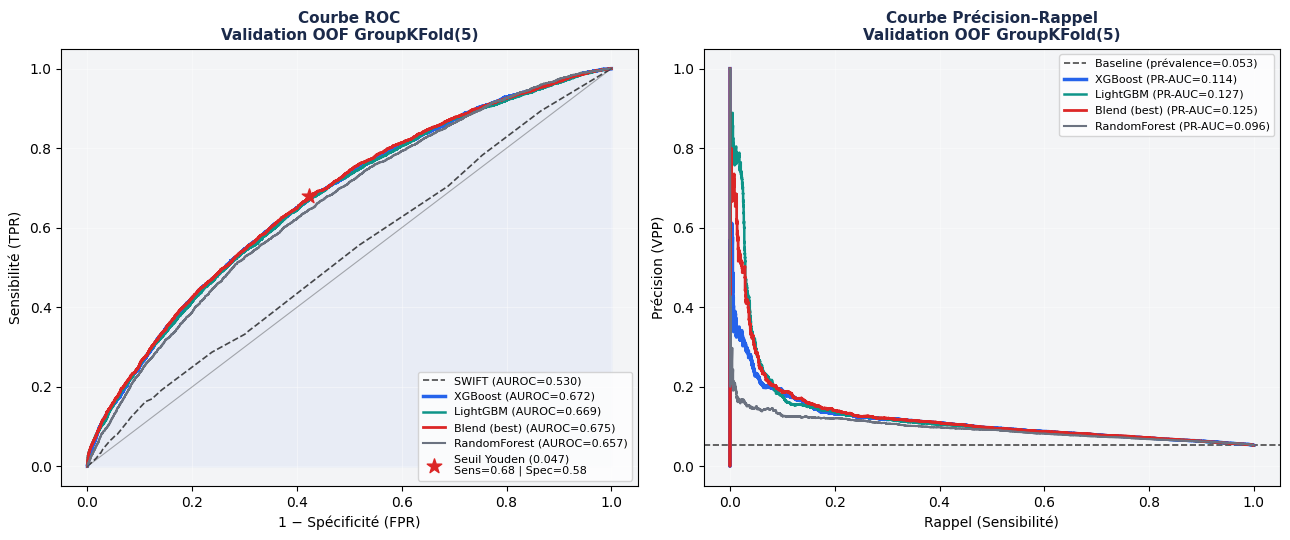

✓ Sauvegardé : figures/fig_roc_pr.png


In [45]:
# ============================================================
# FIGURES — ROC + PR (qualité publication)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')

# ── Données courbes ───────────────────────────────────────
fpr_swift, tpr_swift, _ = roc_curve(y_true,
                                     df['swift_score'].values)

model_curves = {
    'XGBoost':     (oof_xgb,      BLUE,  2.5),
    'LightGBM':    (oof_lgb,      TEAL,  1.8),
    'Blend (best)': (best_blend_oof, RED, 2.0),
}
if 'RandomForest' in all_results:
    model_curves['RandomForest'] = (
        all_results['RandomForest']['oof'], GRAY, 1.5)

# ── ROC ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(fpr_swift, tpr_swift, color='black', lw=1.2,
        linestyle='--', alpha=0.7,
        label=f'SWIFT (AUROC={SWIFT_AUROC:.3f})')

for name, (oof_p, color, lw) in model_curves.items():
    _fpr, _tpr, _thr = roc_curve(y_true, oof_p)
    _auc = roc_auc_score(y_true, oof_p)
    ax.plot(_fpr, _tpr, color=color, lw=lw,
            label=f'{name} (AUROC={_auc:.3f})')

# Point Youden sur le meilleur modèle
ax.scatter(fpr[youden_idx], tpr[youden_idx],
           color=RED, s=120, zorder=6, marker='*',
           label=f'Seuil Youden ({best_thr:.3f})\n'
                 f'Sens={sensitivity:.2f} | Spec={specificity:.2f}')

ax.plot([0,1],[0,1], 'k-', lw=0.8, alpha=0.3)
ax.fill_between(fpr, tpr, alpha=0.05, color=BLUE)
ax.set_xlabel('1 − Spécificité (FPR)', fontsize=10)
ax.set_ylabel('Sensibilité (TPR)', fontsize=10)
ax.set_title('Courbe ROC\nValidation OOF GroupKFold(5)',
             fontsize=11, fontweight='bold', color=NAVY)
ax.legend(fontsize=8, loc='lower right')
ax.set_facecolor(LGRAY)
ax.grid(True, alpha=0.4, color='white')

# ── PR ────────────────────────────────────────────────────
ax = axes[1]
baseline_pr = y_true.mean()
ax.axhline(baseline_pr, color='black', lw=1.2, linestyle='--',
           alpha=0.7, label=f'Baseline (prévalence={baseline_pr:.3f})')

for name, (oof_p, color, lw) in model_curves.items():
    prec, rec, _ = precision_recall_curve(y_true, oof_p)
    _prauc = average_precision_score(y_true, oof_p)
    ax.plot(rec, prec, color=color, lw=lw,
            label=f'{name} (PR-AUC={_prauc:.3f})')

ax.set_xlabel('Rappel (Sensibilité)', fontsize=10)
ax.set_ylabel('Précision (VPP)', fontsize=10)
ax.set_title('Courbe Précision–Rappel\nValidation OOF GroupKFold(5)',
             fontsize=11, fontweight='bold', color=NAVY)
ax.legend(fontsize=8, loc='upper right')
ax.set_facecolor(LGRAY)
ax.grid(True, alpha=0.4, color='white')

plt.tight_layout()
plt.savefig('../figures/fig_roc_pr.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Sauvegardé : figures/fig_roc_pr.png")

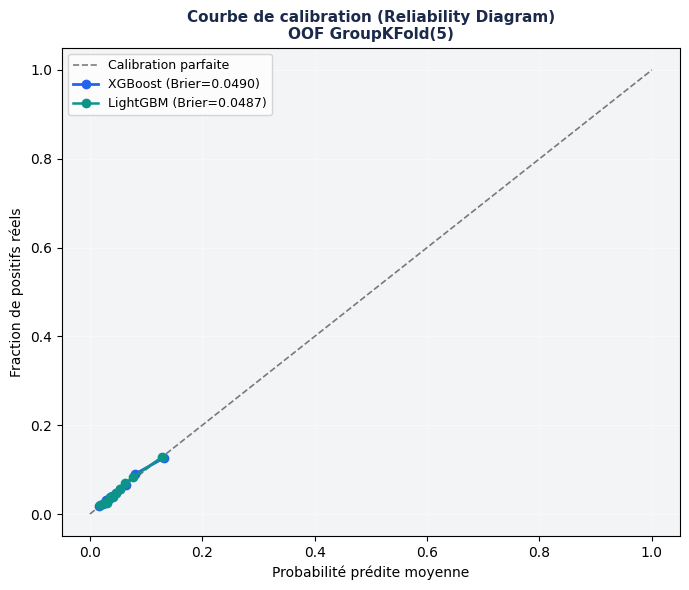

✓ Sauvegardé : figures/fig_calibration.png


In [46]:
# ============================================================
# CALIBRATION — Reliability diagram
# Vérifie que les probabilités prédites sont bien calibrées
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('white')

ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.5,
        label='Calibration parfaite')

for name, (oof_p, color, lw) in {
    'XGBoost':  (oof_xgb,  BLUE, 2.0),
    'LightGBM': (oof_lgb,  TEAL, 1.8),
}.items():
    prob_true, prob_pred = calibration_curve(
        y_true, oof_p, n_bins=10, strategy='quantile')
    bs = brier_score_loss(y_true, oof_p)
    ax.plot(prob_pred, prob_true, marker='o', color=color, lw=lw,
            label=f'{name} (Brier={bs:.4f})')

ax.set_xlabel('Probabilité prédite moyenne', fontsize=10)
ax.set_ylabel('Fraction de positifs réels', fontsize=10)
ax.set_title('Courbe de calibration (Reliability Diagram)\n'
             'OOF GroupKFold(5)', fontsize=11,
             fontweight='bold', color=NAVY)
ax.legend(fontsize=9)
ax.set_facecolor(LGRAY)
ax.grid(True, alpha=0.4, color='white')

plt.tight_layout()
plt.savefig('../figures/fig_calibration.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Sauvegardé : figures/fig_calibration.png")

# Note : si la courbe est sous la diagonale → modèle sur-confiant
# Calibration isotonic sera appliquée si nécessaire

Entraînement final pour SHAP (fold 1)...
✓ SHAP calculé sur 1000 observations


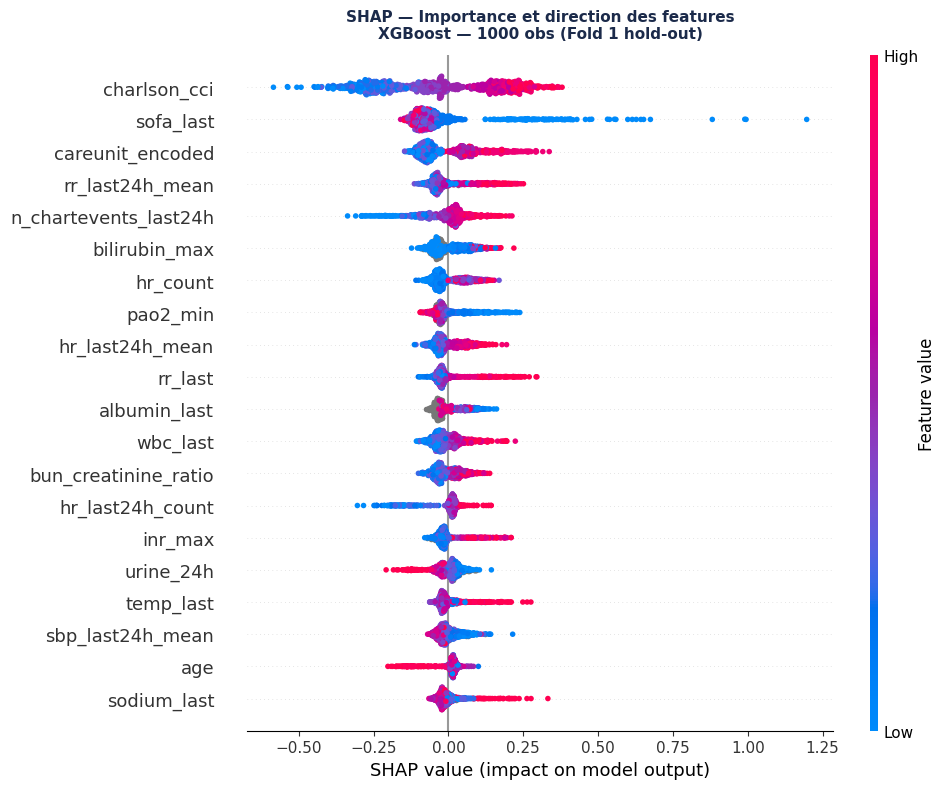

✓ Sauvegardé : figures/fig_shap_beeswarm.png


In [47]:
# ============================================================
# SHAP — Interprétabilité du meilleur modèle
# Entraîner une dernière fois sur 80% des données
# pour calculer les SHAP values sur le hold-out final
# ============================================================
import shap

print("Entraînement final pour SHAP (fold 1)...")

# On prend le fold 1 comme hold-out de référence
train_idx, val_idx = list(sgkf.split(X, y, groups))[0]

X_train_raw = X.iloc[train_idx].values.astype(float)
X_val_raw   = X.iloc[val_idx].values.astype(float)
y_train_shap = y.iloc[train_idx]
y_val_shap   = y.iloc[val_idx]

p1, p99     = winsorize_fit(X_train_raw)
X_train_w   = winsorize_apply(X_train_raw, p1, p99)
X_val_w     = winsorize_apply(X_val_raw,   p1, p99)

X_tr, X_es, y_tr, y_es = train_test_split(
    X_train_w, y_train_shap,
    test_size=0.1, stratify=y_train_shap, random_state=RANDOM_STATE
)

model_shap = xgb.XGBClassifier(
    n_estimators=1500, learning_rate=0.05, max_depth=6,
    scale_pos_weight=1, subsample=0.8, colsample_bytree=0.8,
    min_child_weight=10, reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='auc', early_stopping_rounds=50,
    tree_method='hist', random_state=RANDOM_STATE,
    n_jobs=-1, verbosity=0,
)
model_shap.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)

# SHAP sur le fold de validation (1000 samples max pour rapidité)
n_shap = min(1000, len(X_val_w))
X_shap_df = pd.DataFrame(X_val_w[:n_shap], columns=feature_cols)

explainer   = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_shap_df)

print(f"✓ SHAP calculé sur {n_shap} observations")

# ── Beeswarm plot (top 20 features) ──────────────────────
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_df,
                  max_display=20, show=False,
                  plot_size=None)
plt.title('SHAP — Importance et direction des features\n'
          f'XGBoost — {n_shap} obs (Fold 1 hold-out)',
          fontsize=11, fontweight='bold', color=NAVY, pad=12)
plt.tight_layout()
plt.savefig('../figures/fig_shap_beeswarm.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Sauvegardé : figures/fig_shap_beeswarm.png")

In [48]:
# ============================================================
# COMPARAISON HORIZONS — J7 / J14 / J30
# Même pipeline XGBoost, même CV
# ============================================================

results_horizons = {}

for target in ['readmit_7d', 'readmit_14d', 'readmit_30d']:
    y_t = df[target].copy()
    print(f"\n{'='*50}")
    print(f"  Horizon : {target} "
          f"({y_t.sum():,} pos, {y_t.mean()*100:.1f}%)")
    print(f"{'='*50}")

    fold_res = []
    oof_p    = np.zeros(len(X))

    for fold, (train_idx, val_idx) in enumerate(
            sgkf.split(X, y_t, groups)):

        X_train_raw = X.iloc[train_idx].values.astype(float)
        X_val_raw   = X.iloc[val_idx].values.astype(float)
        y_train     = y_t.iloc[train_idx]
        y_val       = y_t.iloc[val_idx]

        p1, p99   = winsorize_fit(X_train_raw)
        X_train_w = winsorize_apply(X_train_raw, p1, p99)
        X_val_w   = winsorize_apply(X_val_raw,   p1, p99)

        X_tr, X_es, y_tr, y_es = train_test_split(
            X_train_w, y_train,
            test_size=0.1, stratify=y_train,
            random_state=RANDOM_STATE
        )

        m = xgb.XGBClassifier(
            n_estimators=1500, learning_rate=0.05,
            max_depth=6, scale_pos_weight=1, subsample=0.8,
            colsample_bytree=0.8, min_child_weight=10,
            reg_alpha=0.1, reg_lambda=1.0, eval_metric='auc',
            early_stopping_rounds=50, tree_method='hist',
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
        )
        m.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)

        y_proba = m.predict_proba(X_val_w)[:, 1]
        oof_p[val_idx] = y_proba

        auroc = roc_auc_score(y_val, y_proba)
        prauc = average_precision_score(y_val, y_proba)
        brier = brier_score_loss(y_val, y_proba)
        fold_res.append({'fold': fold+1, 'auroc': auroc,
                         'prauc': prauc, 'brier': brier})
        print_fold_metrics(fold, auroc, prauc, brier)

    df_h = pd.DataFrame(fold_res)
    oof_auroc_h = roc_auc_score(y_t, oof_p)
    results_horizons[target] = {
        'scores': df_h,
        'oof': oof_p,
        'oof_auroc': oof_auroc_h
    }
    print(f"\n  OOF AUROC {target} : {oof_auroc_h:.4f}")

# Résumé comparatif
print(f"\n{'='*45}")
print(f"{'Horizon':<15} {'AUROC cv':>10} {'OOF AUROC':>10}")
print(f"{'─'*45}")
for target, res in results_horizons.items():
    print(f"{target:<15} "
          f"{res['scores']['auroc'].mean():>10.4f} "
          f"{res['oof_auroc']:>10.4f}")


  Horizon : readmit_7d (3,144 pos, 5.3%)
  Fold 1 | AUROC=0.6691 | PR-AUC=0.1173 | Brier=0.0490
  Fold 2 | AUROC=0.6529 | PR-AUC=0.0996 | Brier=0.0495
  Fold 3 | AUROC=0.6724 | PR-AUC=0.1110 | Brier=0.0490
  Fold 4 | AUROC=0.6759 | PR-AUC=0.1195 | Brier=0.0490
  Fold 5 | AUROC=0.6958 | PR-AUC=0.1487 | Brier=0.0484

  OOF AUROC readmit_7d : 0.6720

  Horizon : readmit_14d (3,709 pos, 6.3%)
  Fold 1 | AUROC=0.6963 | PR-AUC=0.1525 | Brier=0.0564
  Fold 2 | AUROC=0.6954 | PR-AUC=0.1401 | Brier=0.0567
  Fold 3 | AUROC=0.6728 | PR-AUC=0.1348 | Brier=0.0570
  Fold 4 | AUROC=0.6811 | PR-AUC=0.1323 | Brier=0.0569
  Fold 5 | AUROC=0.6918 | PR-AUC=0.1467 | Brier=0.0566

  OOF AUROC readmit_14d : 0.6874

  Horizon : readmit_30d (3,922 pos, 6.6%)
  Fold 1 | AUROC=0.6892 | PR-AUC=0.1481 | Brier=0.0596
  Fold 2 | AUROC=0.7053 | PR-AUC=0.1540 | Brier=0.0594
  Fold 3 | AUROC=0.6893 | PR-AUC=0.1594 | Brier=0.0593
  Fold 4 | AUROC=0.7141 | PR-AUC=0.1696 | Brier=0.0588
  Fold 5 | AUROC=0.6877 | PR-AUC=0.

In [49]:
# ============================================================
# RÉCAPITULATIF FINAL — Tableau de synthèse complet
# ============================================================

print("\n" + "="*68)
print("  RÉSULTATS FINAUX — Prédiction Réadmission ICU J7 | MIMIC-IV")
print("="*68)
print(f"\n  Cohorte    : 59 260 séjours | 5,3% réadmis J7")
print(f"  Validation : StratifiedGroupKFold(5) par patient")
print(f"  Features   : {len(feature_cols)} variables\n")

print(f"{'MODÈLE':<22} {'AUROC cv':>9} {'±':>6} "
      f"{'PR-AUC':>8} {'Brier':>8} {'OOF':>8}")
print("─"*65)
print(f"{'SWIFT (baseline)':<22} {SWIFT_AUROC:>9.4f} {'':>6} "
      f"{SWIFT_PRAUC:>8.4f} {SWIFT_BRIER:>8.4f} {'—':>8}")

for name, res in all_results.items():
    if 'scores' in res:
        df_r = res['scores']
        print(f"{name:<22} {df_r['auroc'].mean():>9.4f} "
              f"±{df_r['auroc'].std():>5.4f} "
              f"{df_r['prauc'].mean():>8.4f} "
              f"{df_r['brier'].mean():>8.4f} "
              f"{res['oof_auroc']:>8.4f}")
    else:
        print(f"{'  ' + name:<22} {'—':>9} {'':>6} {'—':>8} "
              f"{'—':>8} {res['oof_auroc']:>8.4f}")

print("─"*65)
print(f"\n  Littérature (external validation sur MIMIC) :")
print(f"  Shi 2022 ext. MIMIC-IV    : 0.60")
print(f"  Neves 2024 eICU→MIMIC-IV  : 0.68–0.70")
print(f"  iREAD 2025 MIMIC-III ext. : 0.768")
print(f"  Objectif rapport          : > 0.75")

print(f"\n  Fichiers sauvegardés :")
print(f"  ../data/oof_xgb_final.npy")
print(f"  ../data/oof_lgb_final.npy")
print(f"  ../data/oof_blend_final.npy")
print(f"  ../data/shap_importance.csv")
print(f"  ../figures/fig_roc_pr.png")
print(f"  ../figures/fig_calibration.png")
print(f"  ../figures/fig_shap_beeswarm.png")
print(f"  ../figures/fig_shap_bar.png")


  RÉSULTATS FINAUX — Prédiction Réadmission ICU J7 | MIMIC-IV

  Cohorte    : 59 260 séjours | 5,3% réadmis J7
  Validation : StratifiedGroupKFold(5) par patient
  Features   : 104 variables

MODÈLE                  AUROC cv      ±   PR-AUC    Brier      OOF
─────────────────────────────────────────────────────────────────
SWIFT (baseline)          0.5303          0.0598   0.0720        —
XGBoost                   0.6732 ±0.0154   0.1192   0.0490   0.6720
LightGBM                  0.6695 ±0.0171   0.1307   0.0487   0.6686
RandomForest              0.6571 ±0.0162   0.0976   0.1293   0.6566
LogisticReg               0.6566 ±0.0161   0.0951   0.2279   0.6564
  Blend (best)                 —               —        —   0.6745
─────────────────────────────────────────────────────────────────

  Littérature (external validation sur MIMIC) :
  Shi 2022 ext. MIMIC-IV    : 0.60
  Neves 2024 eICU→MIMIC-IV  : 0.68–0.70
  iREAD 2025 MIMIC-III ext. : 0.768
  Objectif rapport          : > 0.75

  Fi